In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors


In [2]:
def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]

    return expIdx, fightbouts
EXP_id , fightbout = get_experimentID_fightbouts("/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5")
print(fightbout)

[[     2  31500 175400 143900]]


In [3]:
def prepare_data(path,infight):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[0,1]:fightbout[0,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates

def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

In [5]:
def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]

def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))

    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segment_list = []

    start = 0
    segment_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            D_seg = dpp[seg_idx]
            th1_seg = np.unwrap(theta1[seg_idx])
            th2_seg = np.unwrap(theta2[seg_idx])

            X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
            time_list.append(np.arange(len(seg_idx)))
            segment_list.append(np.full(len(seg_idx), segment_id))

            segment_id += 1
            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_idx = np.concatenate(segment_list)

    return X, time_idx, segment_idx

### Choose the file and if you want total or only in fight

In [ ]:
def Run_Force_inference(d_pp, theta_i, theta_j,K,M):
    X, time_idx, segment_idx =  Build_segmented_data(d_pp, theta_i, theta_j)
    seg_lengths = np.bincount(segment_idx)

    valid_segments = np.where(seg_lengths > 5)[0]
    mask = np.isin(segment_idx, valid_segments)

    X = X[mask]
    time_idx = time_idx[mask]
    segment_idx = segment_idx[mask]

    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01, particle_indices=segment_idx)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    

    def radial_basis(D):
        p_poly = poly_1d(jnp.array([D]))

        lam = jnp.array([1.0,2.5, 6.0])
        p_exp = jnp.exp(-D /lam)

        return p_exp #jnp.concatenate([p_poly,p_exp])

    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p  = poly_1d(jnp.array([D]))
        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = (p[:, None, None] * f1[1:][None, :, None] * f2[1:][None, None, :]).reshape(-1) 
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),
        jnp.outer(p, f2[1:]).reshape(-1),
        triple], axis=0)
        return phi 
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_func},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor

path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
d_pp,theta_i,theta_j = calculate_variables(prepare_data(path,True))
S, descriptor = Run_Force_inference(d_pp,theta_i,theta_j, K=2, M=3) 

Measurement noise trace: -0.035904984921216965.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.035904984921216965). 


In [15]:
print(vars(S).keys())

dict_keys(['data', 'verbosity', 'max_memory_gb', 'Lambda', 'Lambda_trace', 'diffusion_average', 'A', 'A_inv', 'sqrtA', 'sqrtA_inv', '__force_M_mode__', '__force_G_mode__', 'force_basis_names', 'force_basis_linear', 'force_basis_linear_gradient', 'force_G_full', 'force_moments', 'force_sparsifier', 'force_coefficients', 'force_support', 'force_G', 'force_G_pinv', 'force_coefficients_full', 'force_ansatz', 'force_coefficients_covariance', 'force_coefficients_stderr', 'force_information', 'force_predicted_MSE'])


In [10]:
import pickle
import numpy as np

save_dict = {
    "force_coefficients": np.array(S.force_coefficients),
    "diffusion": np.array(S.diffusion_average),
    "basis_names": S.force_basis_names,
    "stderr": np.array(S.force_coefficients_stderr),
}

with open("sfi_model_segmented_M3.pkl", "wb") as f:
    pickle.dump(save_dict, f)

In [265]:
print("Number of descriptors:", len(descriptor))
for i, d in enumerate(descriptor):
    print(i, d)

Number of descriptors: 555
0 b₀·e₀
1 b₁·e₀
2 b₂·e₀
3 b₃·e₀
4 b₄·e₀
5 b₅·e₀
6 b₆·e₀
7 b₇·e₀
8 b₈·e₀
9 b₉·e₀
10 b₁₀·e₀
11 b₁₁·e₀
12 b₁₂·e₀
13 b₁₃·e₀
14 b₁₄·e₀
15 b₁₅·e₀
16 b₁₆·e₀
17 b₁₇·e₀
18 b₁₈·e₀
19 b₁₉·e₀
20 b₂₀·e₀
21 b₂₁·e₀
22 b₂₂·e₀
23 b₂₃·e₀
24 b₂₄·e₀
25 b₂₅·e₀
26 b₂₆·e₀
27 b₂₇·e₀
28 b₂₈·e₀
29 b₂₉·e₀
30 b₃₀·e₀
31 b₃₁·e₀
32 b₃₂·e₀
33 b₃₃·e₀
34 b₃₄·e₀
35 b₃₅·e₀
36 b₃₆·e₀
37 b₃₇·e₀
38 b₃₈·e₀
39 b₃₉·e₀
40 b₄₀·e₀
41 b₄₁·e₀
42 b₄₂·e₀
43 b₄₃·e₀
44 b₄₄·e₀
45 b₄₅·e₀
46 b₄₆·e₀
47 b₄₇·e₀
48 b₄₈·e₀
49 b₄₉·e₀
50 b₅₀·e₀
51 b₅₁·e₀
52 b₅₂·e₀
53 b₅₃·e₀
54 b₅₄·e₀
55 b₅₅·e₀
56 b₅₆·e₀
57 b₅₇·e₀
58 b₅₈·e₀
59 b₅₉·e₀
60 b₆₀·e₀
61 b₆₁·e₀
62 b₆₂·e₀
63 b₆₃·e₀
64 b₆₄·e₀
65 b₆₅·e₀
66 b₆₆·e₀
67 b₆₇·e₀
68 b₆₈·e₀
69 b₆₉·e₀
70 b₇₀·e₀
71 b₇₁·e₀
72 b₇₂·e₀
73 b₇₃·e₀
74 b₇₄·e₀
75 b₇₅·e₀
76 b₇₆·e₀
77 b₇₇·e₀
78 b₇₈·e₀
79 b₇₉·e₀
80 b₈₀·e₀
81 b₈₁·e₀
82 b₈₂·e₀
83 b₈₃·e₀
84 b₈₄·e₀
85 b₈₅·e₀
86 b₈₆·e₀
87 b₈₇·e₀
88 b₈₈·e₀
89 b₈₉·e₀
90 b₉₀·e₀
91 b₉₁·e₀
92 b₉₂·e₀
93 b₉₃·e₀
94 b₉₄·e₀
95 b₉₅·e₀
96 b₉₆·e₀
97 b₉₇·e₀
98 b₉₈·e₀
99 

In [22]:
def Simulation(S,x0,dt,N_steps,key):
    Diffusion = np.array(S.diffusion_average)

    L = jnp.linalg.cholesky(Diffusion)

    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) * (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 25))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key

t0 = np.random.randint(0, len(d_pp))

x0 = [d_pp[t0],theta_i[t0],theta_j[t0]]

key = random.PRNGKey(0)
traj_sim, key = Simulation(S, x0, dt=0.01, N_steps=500000, key=key)

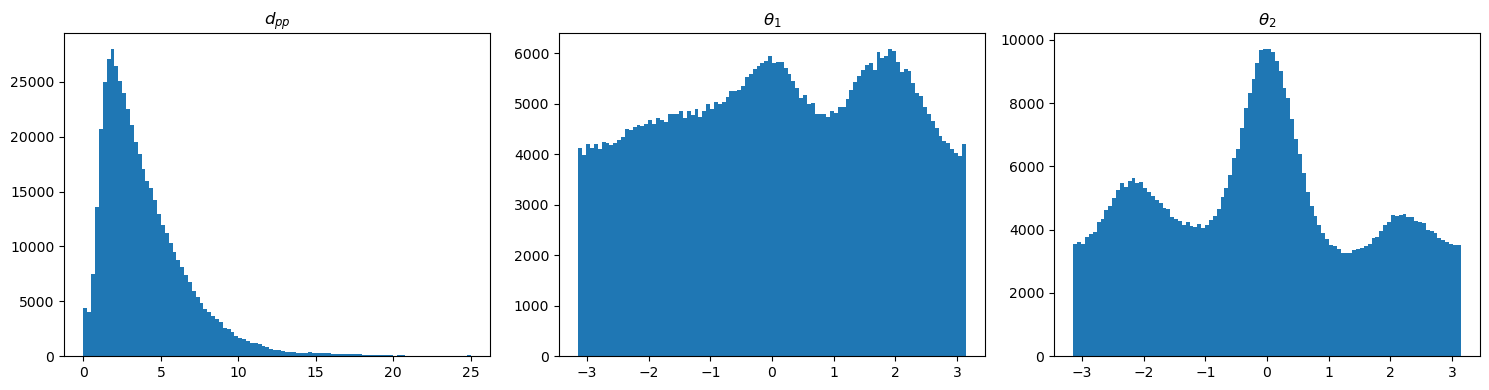

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim[:,0], bins=100)
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(traj_sim[:,1], bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(traj_sim[:,2], bins=100)
axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)

#plt.savefig(f"{save_path}/Distributions_segmentedtrajectories.png", dpi=300)
plt.show()

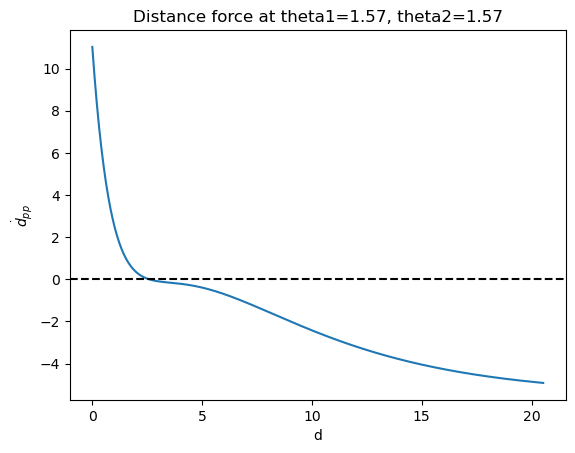

In [18]:
def F(D_vals,theta1_vals,theta2_vals):
    states = jnp.column_stack([D_vals,theta1_vals, theta2_vals])
    F_vals = S.force_ansatz(states)
    dD_dt = np.array(F_vals[:, 0])
    dth1_dt = np.array(F_vals[:, 1])
    dth2_dt = np.array(F_vals[:, 2])
    return dD_dt,dth1_dt,dth2_dt

D_median =5#np.median(d_pp_clean)
theta1 =np.pi/2
theta2 = np.pi/2
distance_vals = np.linspace(0,np.max(d_pp_clean),400)
theta1_vals = np.linspace(-np.pi,np.pi,400)

d_dt,th1_dt,th2_dt = F(distance_vals,np.full(400, theta1),np.full(400, theta2))
os.makedirs("Exploratory_Figures", exist_ok=True)
plt.plot(distance_vals, d_dt)
plt.axhline(0, linestyle='--', color ='k')
plt.xlabel(f'd')
plt.ylabel(r'$\dot{d}_{pp}$')
plt.title(f'Distance force at theta1={theta1:.2f}, theta2={theta2:.2f}')
#plt.savefig("Exploratory_Figures/Forces/Dforce_theta1_0.5pi_theta1_-0.5pi.png")
plt.show()

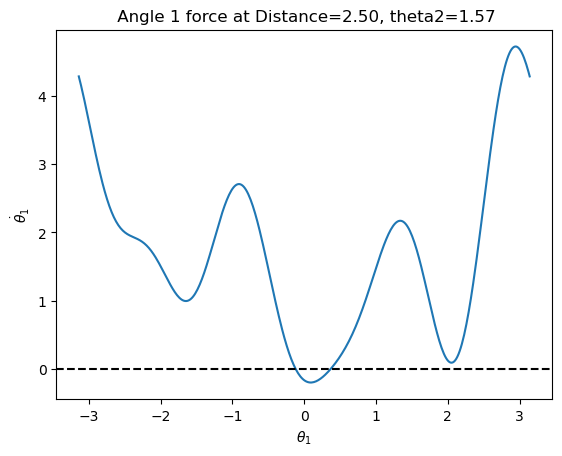

In [239]:
D_value =2.5
theta1 =np.pi/2
theta2 = np.pi/2
distance_vals = np.linspace(0,np.max(d_pp_clean),400)
theta_vals = np.linspace(-np.pi,np.pi,400)

d_dt,th1_dt,th2_dt = F(np.full(400, D_value),theta_vals,np.full(400, theta2))
os.makedirs("Exploratory_Figures", exist_ok=True)
plt.plot(theta_vals,th1_dt)
plt.axhline(0, linestyle='--', color ='k')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\dot{\theta}_{1}$')
plt.title(f' Angle 1 force at Distance={D_value:.2f}, theta2={theta2:.2f}')
plt.savefig("Exploratory_Figures/Forces/th1Force_Distance_2.5_th2_0.5pi.png")
plt.show()

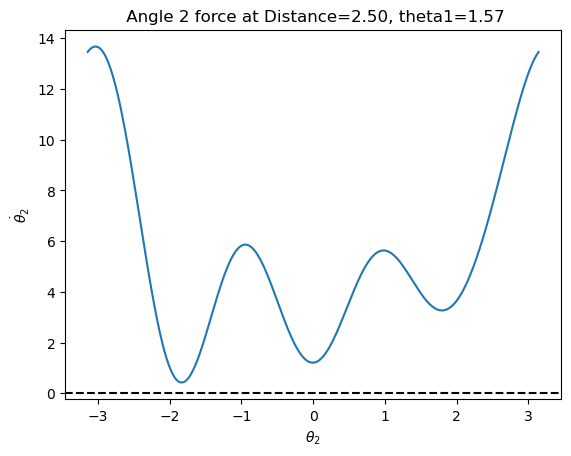

In [241]:
D_value =2.5#np.median(d_pp_clean)
theta1 =np.pi/2
theta2 = np.pi/2
distance_vals = np.linspace(0,np.max(d_pp_clean),400)
theta_vals = np.linspace(-np.pi,np.pi,400)

d_dt,th1_dt,th2_dt = F(np.full(400, D_value),np.full(400, theta1),theta_vals)
os.makedirs("Exploratory_Figures", exist_ok=True)
plt.plot(theta_vals,th2_dt)
plt.axhline(0, linestyle='--', color ='k')
plt.xlabel(r'$\theta_2$')
plt.ylabel(r'$\dot{\theta}_{2}$')
plt.title(f' Angle 2 force at Distance={D_value:.2f}, theta1={theta1:.2f}')
#plt.savefig("Exploratory_Figures/Forces/th2Force_Distance_2.5_th1_0.5pi.png")
plt.show()

Text(0.5, 1.0, 'Heatmap force $F_D$')

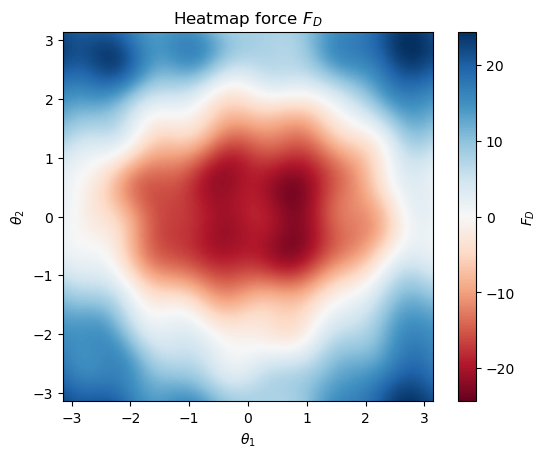

In [264]:
D_value = 10
theta_vals = np.linspace(-np.pi,np.pi,200)
th1, th2 = np.meshgrid(theta_vals,theta_vals)

d_dt,th1_dt,th2_dt = F(np.full(th1.size, D_value),th1.ravel(), th2.ravel())

d_dt = d_dt.reshape(th1.shape)
v = np.max(abs(d_dt))

plt.imshow(d_dt,cmap = 'RdBu',extent=[-np.pi, np.pi, -np.pi, np.pi],vmin=-v,vmax=v,
    origin='lower')
plt.colorbar(label=r'$F_D$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'Heatmap force $F_D$')

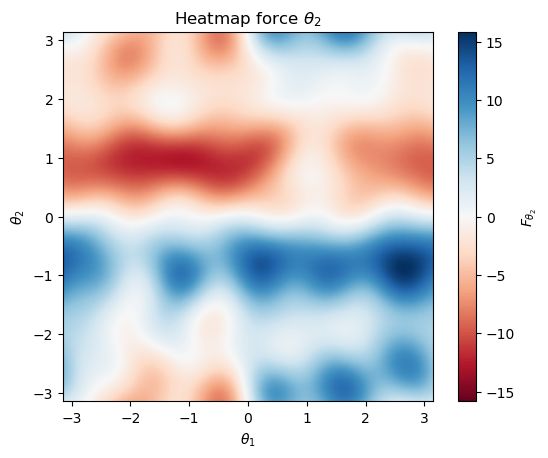

In [260]:
D_value = 6
theta_vals = np.linspace(-np.pi,np.pi,200)
th1, th2 = np.meshgrid(theta_vals,theta_vals)

d_dt,th1_dt,th2_dt = F(np.full(th1.size, D_value),th1.ravel(), th2.ravel())

th2_dt = th2_dt.reshape(th1.shape)
v = np.max(np.abs(th2_dt))
plt.imshow(th2_dt,cmap = 'RdBu',extent=[-np.pi, np.pi, -np.pi, np.pi],vmin=-v,vmax=v,
    origin='lower')
plt.colorbar(label=r'$F_{\theta_2}$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'Heatmap force $\theta_2$')
plt.savefig("Exploratory_Figures/Forces/heatmap_th2Force_Distance_6.png")

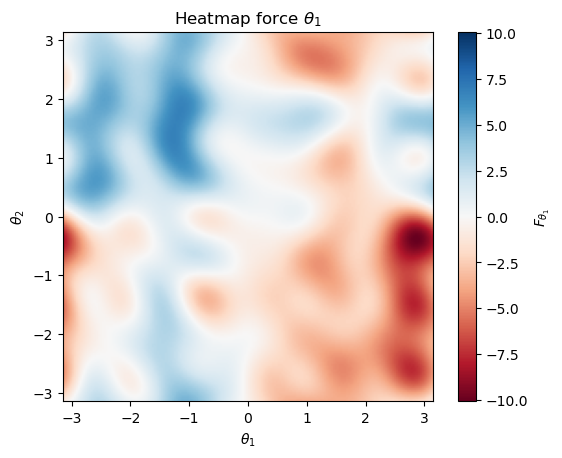

In [261]:
D_value = 6
theta_vals = np.linspace(-np.pi,np.pi,200)
th1, th2 = np.meshgrid(theta_vals,theta_vals)

d_dt,th1_dt,th2_dt = F(np.full(th1.size, D_value),th1.ravel(), th2.ravel())

th1_dt = th1_dt.reshape(th1.shape)
v = np.max(np.abs(th1_dt))
plt.imshow(th1_dt,cmap = 'RdBu',extent=[-np.pi, np.pi, -np.pi, np.pi],vmin=-v,vmax=v,
    origin='lower')
plt.colorbar(label=r'$F_{\theta_1}$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'Heatmap force $\theta_1$')
plt.savefig("Exploratory_Figures/Forces/heatmap_th1Force_Distance_6.png")

In [266]:
Diffusion.shape

(3, 3)

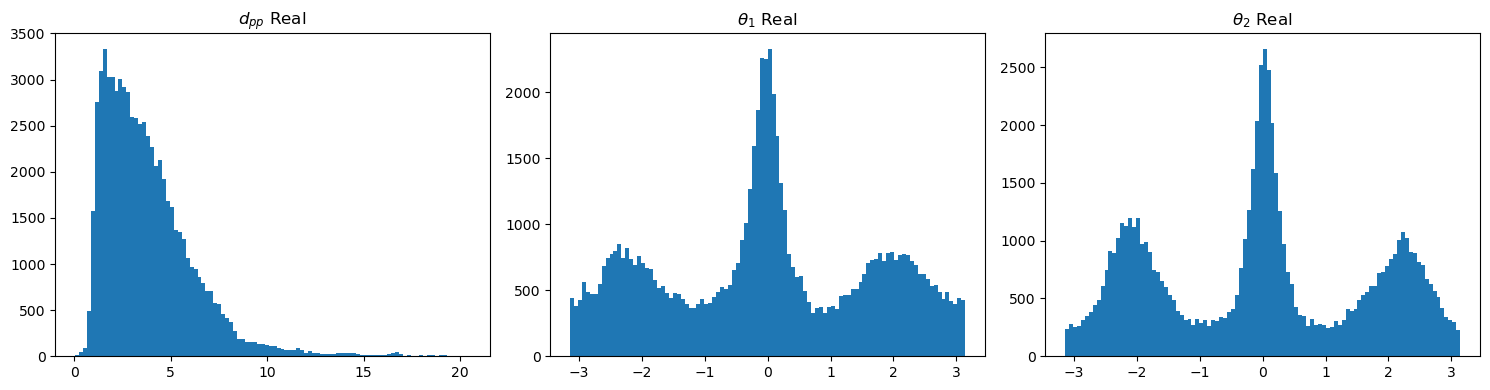

In [479]:
N = len(d_pp_clean)

d_pp_half = d_pp_clean[:N//2]
theta_i_half = theta_i_clean[:N//2]
theta_j_half = theta_j_clean[:N//2]

fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(d_pp_half, bins=100)
axs[0].set_title(r'$d_{pp}$ Real')

axs[1].hist(theta_i_half, bins=100)
axs[1].set_title(r"$\theta_1$ Real")

axs[2].hist(theta_j_half, bins=100)
axs[2].set_title(r"$\theta_2$ Real")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)

#plt.savefig(f"{save_path}/Distributions_Real.png", dpi=300)
plt.show()

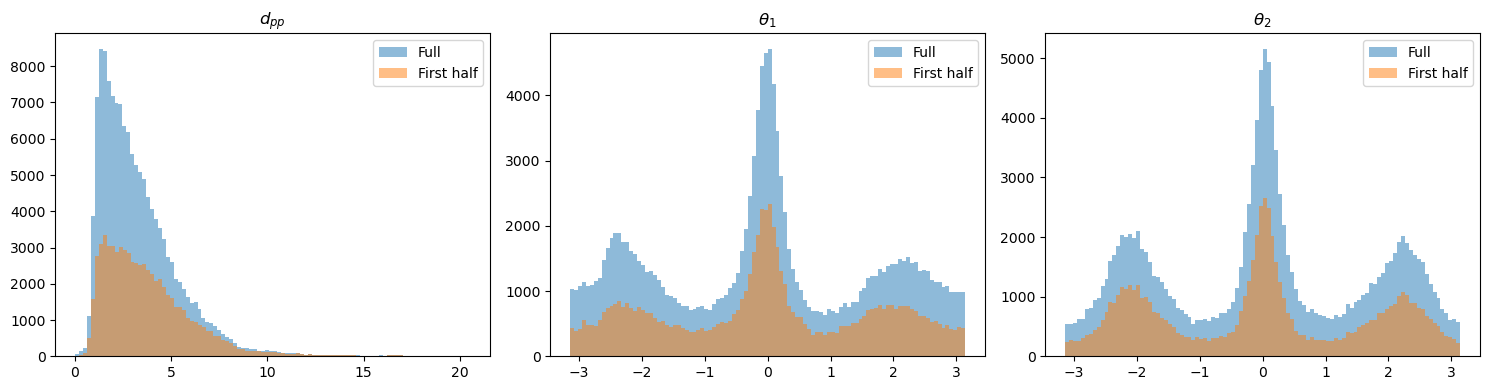

In [431]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

# Distance
axs[0].hist(d_pp_clean, bins=100, alpha=0.5, label='Full')
axs[0].hist(d_pp_half, bins=100, alpha=0.5, label='First half')
axs[0].set_title(r'$d_{pp}$')
axs[0].legend()

# Theta 1
axs[1].hist(theta_i_clean, bins=100, alpha=0.5, label='Full')
axs[1].hist(theta_i_half, bins=100, alpha=0.5, label='First half')
axs[1].set_title(r"$\theta_1$")
axs[1].legend()

# Theta 2
axs[2].hist(theta_j_clean, bins=100, alpha=0.5, label='Full')
axs[2].hist(theta_j_half, bins=100, alpha=0.5, label='First half')
axs[2].set_title(r"$\theta_2$")
axs[2].legend()

plt.tight_layout()
plt.show()

In [269]:
def autocorr(x):
    x = x[np.isfinite(x)] #remove the nans 
    x -= x.mean() #subtract mean
    result = np.correlate(x,x, mode='full') #result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:] # keep only positive values

    return result/result[0]

In [314]:
def Analyse_noise(X,S,L,dt):
    eta_time = np.zeros((len(X[:,1]),3))

    for i in range(len(X[:,1])-1):

        dX = X[i+1,:] - X[i,:]
        F = S.force_ansatz(X[i:i+1, :])[0]
        R = dX - F*dt

        eta = 1/np.sqrt(2*dt)* np.linalg.inv(L) @ R
        eta_time[i,:] = eta
    dpp_autocorr = autocorr(eta_time[:,0])
    th1_autocorr = autocorr(eta_time[:,1])
    th2_autocorr = autocorr(eta_time[:,2])

    return eta_time,dpp_autocorr,th1_autocorr,th2_autocorr

eta_time,dpp_autocorr,th1_autocorr,th2_autocorr = Analyse_noise(X,S,L,dt=0.01)

Variation ξ_dpp = 0.553
Variation ξ_θ1 = 0.952
Variation ξ_θ2 = 0.928
Mean ξ_dpp = 0.000
Mean ξ_θ1 = 0.005
Mean ξ_θ2 = -0.001


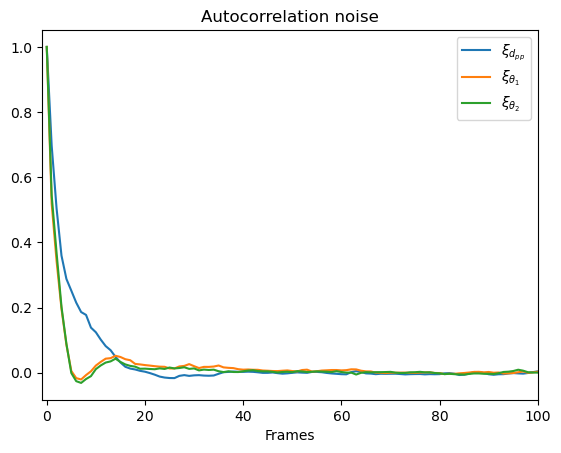

In [318]:
print(f'Variation ξ_dpp = {np.var(eta_time[:,0]):.3f}')
print(f'Variation ξ_θ1 = {np.var(eta_time[:,1]):.3f}')
print(f'Variation ξ_θ2 = {np.var(eta_time[:,2]):.3f}')

print(f'Mean ξ_dpp = {np.mean(eta_time[:,0]):.3f}')
print(f'Mean ξ_θ1 = {np.mean(eta_time[:,1]):.3f}')
print(f'Mean ξ_θ2 = {np.mean(eta_time[:,2]):.3f}')

plt.plot(dpp_autocorr,label=r'$\xi_{d_{pp}}$')
plt.plot(th1_autocorr,label =r'$\xi_{\theta_1}$')
plt.plot(th2_autocorr,label =r'$\xi_{\theta_2}$')
plt.title("Autocorrelation noise")
plt.legend()
plt.xlabel('Frames')
plt.xlim(-1,100)
plt.savefig('Exploratory_Figures/Deterministic_simulation/Autocorrelation.png')


In [389]:
def Simulation_anglesfixed(S, D0, theta1, theta2, dt=0.01, N_steps=5000,
                      early_stop=True, force_tol=1e-4, n_consecutive=20):
    D =  D0
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append([D,theta1,theta2])

        FD = float(S.force_ansatz(np.array([[D, theta1, theta2]]))[0][0])
        D = D + FD * dt

        if early_stop:

            if abs(FD) < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append([D, theta1, theta2])
                break

    return jnp.array(xs)

def Simulation_Dfixed(S,x0,dt,N_steps,D,early_stop= True,force_tol = 1e-4,n_consecutive = 20):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else x[0])
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

        if early_stop:
            drift_new = S.force_ansatz(x[None, :])[0]
            force_norm = np.linalg.norm(np.array([drift_new[1], drift_new[2]]))
            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break

    return jnp.stack(xs)

def Simulation_deterministic(S,x0,dt,N_steps,D,theta1 =None, theta2 = None,early_stop= True,force_tol = 1e-4,n_consecutive = 20):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else x[0])
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0][0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs)

#t0 = np.random.randint(0, len(d_pp_clean))
#x0 = [d_pp_clean[t0], theta_i_clean[t0], theta_j_clean[t0]]
#traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=50000,D=2.5,theta1 =None, theta2 = None,early_stop= True,force_tol = 1e-4,n_consecutive = 20)

2.5


Text(0, 0.5, '$\\theta_2$')

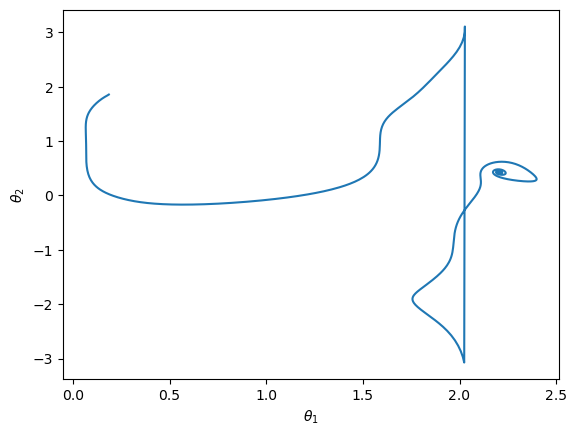

In [386]:
t0 = np.random.randint(0, len(d_pp_clean))
x0 = [d_pp_clean[t0], theta_i_clean[t0], theta_j_clean[t0]]
traj_sim = Simulation_Dfixed(S, x0, dt=0.01, N_steps=5000,D=2.5,early_stop= True,force_tol = 1e-4,n_consecutive = 20)

theta1 = traj_sim[:,1]
theta2 = traj_sim[:,2]
print(traj_sim[-1,0])
plt.plot(theta1,theta2)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')

'\nx0 = [ 3 , 2.62800002 , 0.155]\nx1 = [ 2 , 2.62800002 , 0.155]\nx2 = [ 8 , 2.62800002 , 0.155]\nx3 = [ 6 , 2.62800002 , 0.155]\nx4 = [ 1 , 2.62800002 , 0.155]\ntraj_sim_dpp = Simulation_deterministic(S, x0, dt=0.01, N_steps=5000,D=None,theta1 =x0[1], theta2 = x0[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)\ntraj_sim_dpp_1 = Simulation_deterministic(S, x1, dt=0.01, N_steps=5000,D=None,theta1 =x1[1], theta2 = x1[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)\ntraj_sim_dpp_2 = Simulation_deterministic(S, x2, dt=0.01, N_steps=5000,D=None,theta1 =x2[1], theta2 = x2[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)\ntraj_sim_dpp_3 = Simulation_deterministic(S, x3, dt=0.01, N_steps=5000,D=None,theta1 =x3[1], theta2 = x3[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)\ntraj_sim_dpp_4 = Simulation_deterministic(S, x4, dt=0.01, N_steps=5000,D=None,theta1 =x4[1], theta2 = x4[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)\n\n\nD_final = traj_sim_d

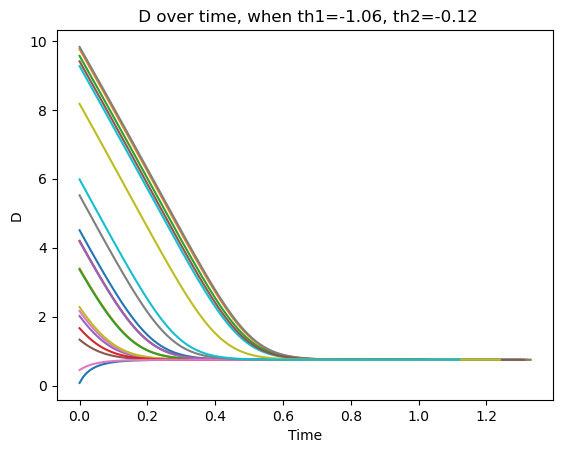

In [405]:
dt = 0.01
for i in range(20):
    x0 =  [ np.random.uniform(0,10), -1.05999994,-0.125 ]
    traj_sim_dpp = Simulation_anglesfixed(S, x0[0], x0[1], x0[2], dt=0.01, N_steps=5000,
                      early_stop=True, force_tol=1e-4, n_consecutive=20)
    t = np.arange(len(traj_sim_dpp)) * dt
    plt.plot(t,traj_sim_dpp[:len(t),0])

plt.xlabel('Time')
plt.ylabel(f'D')
#plt.text(t[380], D_final +0.2, f' D final = {D_final:.2f}', color='red')
plt.title(f' D over time, when th1={x0[1]:.2f}, th2={x0[2]:.2f}')
"""
x0 = [ 3 , 2.62800002 , 0.155]
x1 = [ 2 , 2.62800002 , 0.155]
x2 = [ 8 , 2.62800002 , 0.155]
x3 = [ 6 , 2.62800002 , 0.155]
x4 = [ 1 , 2.62800002 , 0.155]
traj_sim_dpp = Simulation_deterministic(S, x0, dt=0.01, N_steps=5000,D=None,theta1 =x0[1], theta2 = x0[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)
traj_sim_dpp_1 = Simulation_deterministic(S, x1, dt=0.01, N_steps=5000,D=None,theta1 =x1[1], theta2 = x1[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)
traj_sim_dpp_2 = Simulation_deterministic(S, x2, dt=0.01, N_steps=5000,D=None,theta1 =x2[1], theta2 = x2[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)
traj_sim_dpp_3 = Simulation_deterministic(S, x3, dt=0.01, N_steps=5000,D=None,theta1 =x3[1], theta2 = x3[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)
traj_sim_dpp_4 = Simulation_deterministic(S, x4, dt=0.01, N_steps=5000,D=None,theta1 =x4[1], theta2 = x4[2],early_stop= True,force_tol = 1e-4,n_consecutive = 20)


D_final = traj_sim_dpp[-1,0]
plt.plot(t,traj_sim_dpp[:,0])
plt.plot(t,traj_sim_dpp_1[:,0])
plt.plot(t,traj_sim_dpp_2[:,0])
plt.plot(t,traj_sim_dpp_3[:,0])
plt.plot(t,traj_sim_dpp_4[:,0])

"""

[0.5        0.64583333 0.79166667 0.9375     1.08333333 1.22916667
 1.375      1.52083333 1.66666667 1.8125     1.95833333 2.10416667
 2.25       2.39583333 2.54166667 2.6875     2.83333333 2.97916667
 3.125      3.27083333 3.41666667 3.5625     3.70833333 3.85416667
 4.        ]


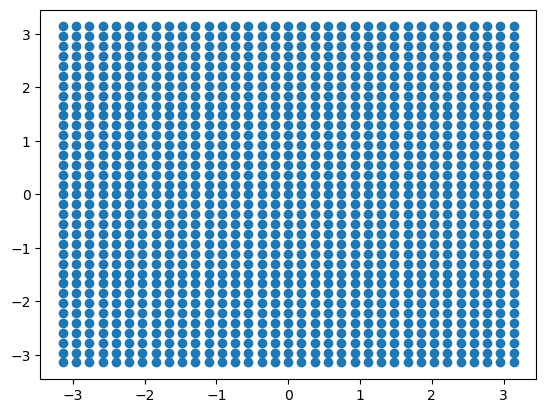

In [472]:

length = np.linspace(-3.14, 3.14, 35)
X, Y = np.meshgrid(length, length)
plt.scatter(X,Y)

D_values = np.linspace(0.5,4,25)
print(D_values)

In [393]:
D_values = np.linspace(0.5,4,20)
accept_rate = []
all_endpoints =[]
for d_sim in D_values:
    Iterations = 150
    all_trajs = np.zeros((Iterations, 5000, 3))
    accepted_trajs = []
    for i in range(Iterations):
        length = np.linspace(-np.pi, np.pi, 20)
        
        t0 = np.random.randint(0, len(d_pp_clean))
        #x0 = [d_sim, theta_i_clean[t0], theta_j_clean[t0]]
        x0 = [d_sim, np.random.uniform(-np.pi, np.pi),np.random.uniform(-np.pi, np.pi)]
        traj_sim = Simulation_Dfixed(S, x0, dt=0.01, N_steps=5000,D=d_sim,early_stop= True,force_tol = 1e-4,n_consecutive = 20)
        if np.linalg.norm(S.force_ansatz(traj_sim[-1][None, :])[0][1:]) < 1e-4:
            accepted_trajs.append(traj_sim)
    accept_rate.append(len(accepted_trajs) / Iterations)
    print('for d=',d_sim, 'accept rate = ',accept_rate)

    endpoints = np.array([traj[-1] for traj in accepted_trajs])
    startpoint = np.array([traj[0] for traj in accepted_trajs])
    all_endpoints.append(endpoints)
    
    plt.figure()
    plt.scatter((startpoint[:,1]), startpoint[:,2], label ='start point')
    plt.scatter((endpoints[:,1]), endpoints[:,2],color = 'r',label = 'end point')
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.title(f'End point deterministic simulation, fixed d={d_sim:.1f}')
    plt.legend()
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/End_point_D={d_sim:.1f}.png')
    plt.close()

    plt.figure()
    plt.hist2d(endpoints[:,1], endpoints[:,2], bins=30,range=[[-np.pi, np.pi], [-np.pi, np.pi]])
    plt.colorbar(label='count')
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.title(f'Endpoint density, d ={d_sim:.1f} ')
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Heatmap_endpoint_D={d_sim:.1f}.png')
    plt.close()
all_endpoints = np.vstack(all_endpoints)


for d= 1 accept rate =  [1.0]
for d= 1.5 accept rate =  [1.0, 1.0]
for d= 1.8 accept rate =  [1.0, 1.0, 0.9133333333333333]
for d= 2.0 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0]
for d= 2.2 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0]
for d= 2.5 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0, 1.0]
for d= 2.8 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0, 1.0, 0.7733333333333333]
for d= 3.0 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0, 1.0, 0.7733333333333333, 1.0]
for d= 3.5 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0, 1.0, 0.7733333333333333, 1.0, 0.76]
for d= 4.0 accept rate =  [1.0, 1.0, 0.9133333333333333, 1.0, 1.0, 1.0, 0.7733333333333333, 1.0, 0.76, 1.0]


In [475]:
def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all

def Find_endpoints(D_values):
    accept_rate = []
    all_endpoints =[]
    
    for d_sim in D_values:
        startpoints = []
        accepted_trajs = []
        length = np.linspace(-np.pi, np.pi, 35,endpoint = False)
        for theta_i0 in length:
            for theta_j0 in length:
                x0 = [d_sim, theta_i0, theta_j0]
                #x0 = [d_sim, np.random.uniform(-np.pi, np.pi),np.random.uniform(-np.pi, np.pi)]
                traj_sim = Simulation_Dfixed(S, x0, dt=0.01, N_steps=5000,D=d_sim,early_stop= True,force_tol = 1e-4,n_consecutive = 20)
                if np.linalg.norm(S.force_ansatz(traj_sim[-1][None, :])[0][1:]) < 1e-4:
                    accepted_trajs.append(traj_sim)
                    startpoints.append(traj_sim[0])
                    
        accept_rate.append(len(accepted_trajs) / (len(length) * len(length)))
        print('for d=',d_sim, 'accept rate = ',accept_rate)

        endpoints = np.array([traj[-1] for traj in accepted_trajs])
        all_endpoints.append(endpoints)
        startpoints = np.array(startpoints)
        

        plt.figure()
        plt.scatter((startpoints[:,1]), startpoints[:,2], label ='start point')
        plt.scatter((endpoints[:,1]), endpoints[:,2],color = 'r',label = 'end point')
        plt.xlabel(r'$\theta_1$')
        plt.ylabel(r'$\theta_2$')
        plt.title(f'End point deterministic simulation, fixed d={d_sim:.1f}')
        plt.legend()
        plt.savefig(f'Exploratory_Figures/Deterministic_simulation/1End_point_D={d_sim:.1f}.png')
        plt.close()

        plt.figure()
        plt.hist2d(endpoints[:,1], endpoints[:,2], bins=30,range=[[-np.pi, np.pi], [-np.pi, np.pi]])
        plt.colorbar(label='count')
        plt.xlabel(r'$\theta_1$')
        plt.ylabel(r'$\theta_2$')
        plt.title(f'Endpoint density, d ={d_sim:.1f} ')
        plt.savefig(f'Exploratory_Figures/Deterministic_simulation/1Heatmap_endpoint_D={d_sim:.1f}.png')
        plt.close()
    all_endpoints = np.vstack(all_endpoints)
    clustered_all = endpoint_clustering(all_endpoints)
    return clustered_all, accept_rate

D_values = np.linspace(0.5,4,50)
D_values = np.concatenate([
    np.linspace(0.5, 4.0, 35, endpoint=False),
    np.linspace(4.0, 6.0, 15, endpoint=False),
    np.linspace(6.0, 8.0, 10)
])
clustered_endpoints, accept_rate = Find_endpoints(D_values)
np.savetxt("endpoints_longerr.csv",clustered_endpoints,delimiter=",",header="d,theta1,theta2",comments="")

for d= 0.5 accept rate =  [1.0]
for d= 0.5714285714285714 accept rate =  [1.0, 1.0]
for d= 0.6428571428571428 accept rate =  [1.0, 1.0, 1.0]
for d= 0.7142857142857143 accept rate =  [1.0, 1.0, 1.0, 1.0]
for d= 0.7857142857142857 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0]
for d= 0.8571428571428571 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 0.9285714285714286 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.0 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.0714285714285714 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.1428571428571428 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.2142857142857142 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.2857142857142856 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.3571428571428572 accept rate =  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
for d= 1.4285714285714284 acc

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_1503/3255499124.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


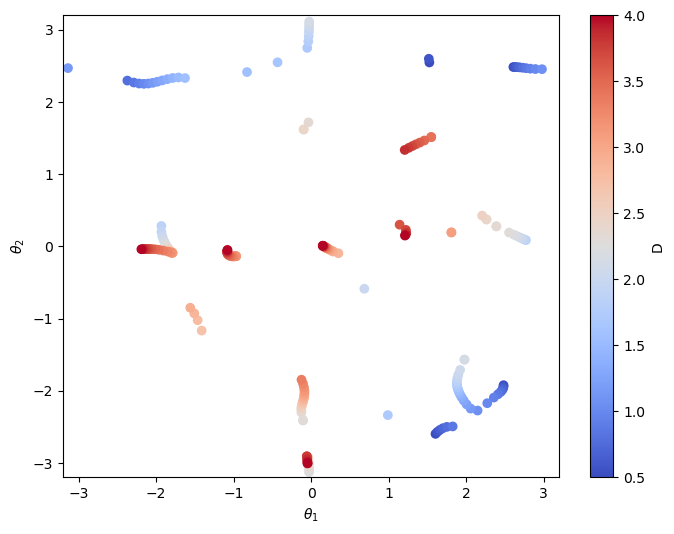

In [478]:
import pandas as pd
clustered_all = pd.read_csv("endpoints_longerr.csv").values
D_values = np.unique(clustered_all[:,0])
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=D_values.min(), vmax=D_values.max())
colors = cmap(norm(D_values))

plt.figure(figsize=(8,6))
sc = plt.scatter(clustered_all[:,1], clustered_all[:,2],
                 c=clustered_all[:,0],
                 cmap='coolwarm')

cbar = plt.colorbar(sc)
cbar.set_label("D")

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(-3.2,3.2)
plt.ylim(-3.2,3.2)
plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Endpoint_distribution.png')
plt.show()


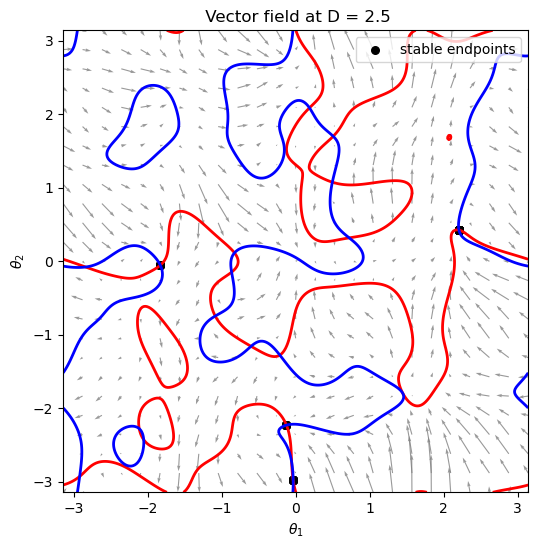

In [404]:
D_value = 2.5
theta_vals = np.linspace(-np.pi, np.pi, 300)
th1, th2 = np.meshgrid(theta_vals, theta_vals)

d_dt, th1_dt, th2_dt = F(
    np.full(th1.size, D_value),
    th1.ravel(),
    th2.ravel()
)

th1_dt = th1_dt.reshape(th1.shape)
th2_dt = th2_dt.reshape(th2.shape)

theta_vals_q = np.linspace(-np.pi, np.pi, 25)
th1_q, th2_q = np.meshgrid(theta_vals_q, theta_vals_q)

_, th1_dt_q, th2_dt_q = F(np.full(th1_q.size, D_value),th1_q.ravel(),th2_q.ravel())

plt.figure(figsize=(6,6))
plt.contour(th1, th2, th1_dt, levels=[0], colors='red', linewidths=2)
plt.contour(th1, th2, th2_dt, levels=[0], colors='blue', linewidths=2)
plt.quiver(th1_q, th2_q, th1_dt_q, th2_dt_q, color='gray', alpha=0.8)
mask = np.isclose(all_endpoints[:, 0], D_value)
endpoints_D = all_endpoints[mask]
plt.scatter(endpoints_D[:,1], endpoints_D[:,2], c='k', s=30, label='stable endpoints')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(f' Vector field at D = {D_value}')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.legend()
plt.show()

In [125]:
Theta1 = [2.2]
Theta2 = [0.8]
accept_rate = []
all_endpoints =[]
Iterations = 100
for k in range(len(Theta1)):
    accepted_trajs = []
    for i in range(Iterations):
        t0 = np.random.randint(0, len(d_pp_clean))
        #x0 = [d_sim, theta_i_clean[t0], theta_j_clean[t0]]
        x0 = [np.random.uniform(0,10), Theta1[k],Theta2[k]]
        traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=5000,D=None,theta1 =Theta1[k], theta2 = Theta2[k])
        if np.linalg.norm(S.force_ansatz(traj_sim[-1][None, :])[0][0]) < 1e-4:
            accepted_trajs.append(traj_sim)
    accept_rate.append(len(accepted_trajs) / Iterations)
    print('for th1=',Theta1[k],'and th2 =,',Theta2[k] ,'accept rate = ',accept_rate)

    endpoints = np.array([traj[-1] for traj in accepted_trajs])
    startpoint = np.array([traj[0] for traj in accepted_trajs])
    all_endpoints.append(endpoints)
    
    plt.figure()
    plt.scatter((startpoint[:,0]), endpoints[:,0], label ='start point')
    plt.xlabel(r'initial $D$')
    plt.ylabel(r'final $D$')
    plt.title(f'End point deterministic simulation, fixed th1={Theta1[k]:.1f} and {Theta2[k]}')
    plt.legend()
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()

    plt.figure()
    plt.hist(endpoints[:,0], bins=30,range=[0,20])
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.title(f'Endpoint density, fixed th1={Theta1[k]:.1f} and {Theta2[k]} ')
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Histogram_End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()
all_endpoints = np.vstack(all_endpoints)

for th1= 2.2 and th2 =, 0.8 accept rate =  [1.0]


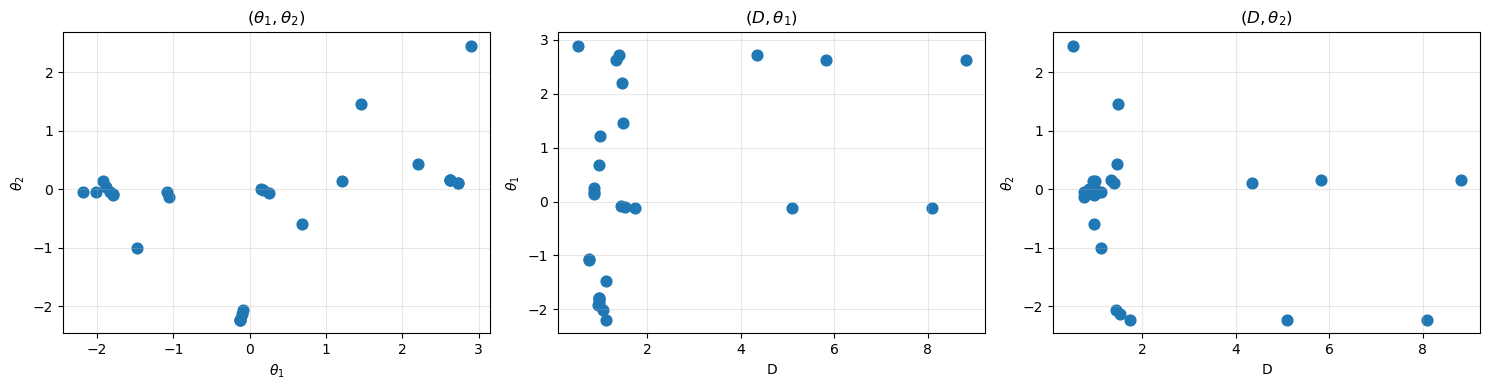

In [408]:

D_vals = np.linspace(0, 12, 2000)
roots =[]
for i in range(len(clustered_all[:,0])):
    point = clustered_all[i,:]
    FD_vals = [float(S.force_ansatz(np.array([[D,point[1],point[2]]]))[0][0]) for D in D_vals]
    idx = np.where(np.sign(FD_vals[:-1]) != np.sign(FD_vals[1:]))[0]
    
    for j in idx:
        D_root = 0.5 * (D_vals[j] + D_vals[j+1])
        roots.append([D_root, point[1], point[2]])

roots = np.array(roots)
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].scatter(roots[:,1],roots[:,2], s=60)
axes[0].set_xlabel(r'$\theta_1$')
axes[0].set_ylabel(r'$\theta_2$')
axes[0].set_title(r'$(\theta_1,\theta_2)$')

axes[1].scatter(roots[:,0], roots[:,1], s=60)
axes[1].set_xlabel('D')
axes[1].set_ylabel(r'$\theta_1$')
axes[1].set_title(r'$(D,\theta_1)$')

axes[2].scatter(roots[:,0], roots[:,2], s=60)
axes[2].set_xlabel('D')
axes[2].set_ylabel(r'$\theta_2$')
axes[2].set_title(r'$(D,\theta_2)$')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

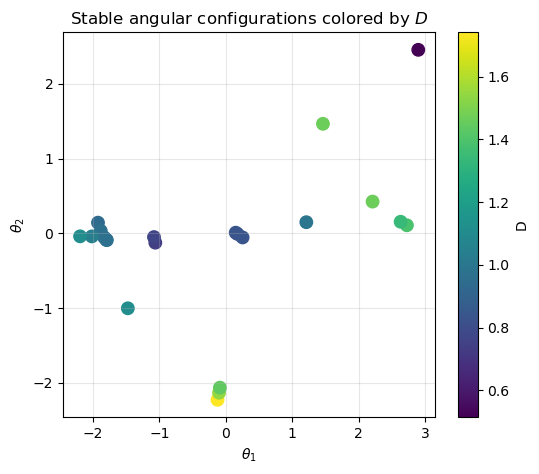

In [216]:
plt.figure(figsize=(6,5))
sc = plt.scatter(roots[:,1], roots[:,2], c=roots[:,0], s=80)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'Stable angular configurations colored by $D$')
plt.colorbar(sc, label='D')
plt.grid(True, alpha=0.3)
plt.show()

In [412]:
for r in roots:
    print(f'D={r[0]:.3f}, th1={r[1]:.3f}, th2={r[2]:.3f}')

D=0.507, th1=2.893, th2=2.456
D=0.939, th1=-1.922, th2=0.143
D=0.957, th1=0.686, th2=-0.588
D=1.390, th1=2.722, th2=0.108
D=4.343, th1=2.722, th2=0.108
D=0.963, th1=-1.880, th2=0.033
D=1.336, th1=2.628, th2=0.155
D=5.832, th1=2.628, th2=0.155
D=8.809, th1=2.628, th2=0.155
D=0.975, th1=-1.829, th2=-0.053
D=1.744, th1=-0.125, th2=-2.228
D=5.088, th1=-0.125, th2=-2.228
D=8.083, th1=-0.125, th2=-2.228
D=1.456, th1=2.206, th2=0.425
D=0.969, th1=-1.797, th2=-0.085
D=1.114, th1=-1.473, th2=-1.003
D=1.528, th1=-0.102, th2=-2.133
D=0.963, th1=-1.789, th2=-0.091
D=1.444, th1=-0.089, th2=-2.065
D=0.849, th1=0.252, th2=-0.055
D=1.042, th1=-2.014, th2=-0.041
D=0.747, th1=-1.060, th2=-0.125
D=0.849, th1=0.175, th2=-0.008
D=1.480, th1=1.460, th2=1.466
D=1.108, th1=-2.191, th2=-0.040
D=0.759, th1=-1.080, th2=-0.050
D=0.849, th1=0.149, th2=0.009
D=0.993, th1=1.210, th2=0.149


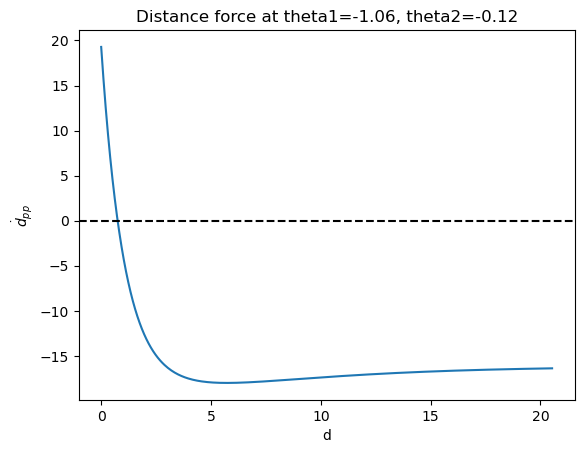

In [402]:
theta1 = -1.05999994 
theta2 = -0.125 
distance_vals = np.linspace(0,np.max(d_pp_clean),400)
theta1_vals = np.linspace(-np.pi,np.pi,400)

d_dt,th1_dt,th2_dt = F(distance_vals,np.full(400, theta1),np.full(400, theta2))
os.makedirs("Exploratory_Figures", exist_ok=True)
plt.plot(distance_vals, d_dt)
plt.axhline(0, linestyle='--', color ='k')
plt.xlabel(f'd')
plt.ylabel(r'$\dot{d}_{pp}$')
plt.title(f'Distance force at theta1={theta1:.2f}, theta2={theta2:.2f}')
#plt.savefig("Exploratory_Figures/Forces/Dforce_theta1_0.5pi_theta1_-0.5pi.png")
plt.show()